# Session 25: Linear, Ridge, Lasso, and Elastic Net
**Week 3 Baseline Regression Models**

This notebook trains and evaluates four interpretable regression baselines:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Elastic Net Regression

The models use the same full-information training and test split. Their test performance is compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared ($R^2$). The primary ranking metric is RMSE.

In [3]:
from pathlib import Path
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Resolve project directories
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / ".git").exists():
    # If run inside notebooks/, move up to project root
    for parent in PROJECT_ROOT.parents:
        if (parent / ".git").exists():
            PROJECT_ROOT = parent
            break

DATA_DIRECTORY = PROJECT_ROOT / "data"
PROCESSED_DIRECTORY = DATA_DIRECTORY / "processed"
REPORTS_DIRECTORY = PROJECT_ROOT / "reports"
TABLES_DIRECTORY = REPORTS_DIRECTORY / "tables"

TABLES_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed-data directory:", PROCESSED_DIRECTORY)
print("Output-table directory:", TABLES_DIRECTORY)

Project root: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml
Processed-data directory: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/data/processed
Output-table directory: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/tables


In [4]:
REQUIRED_SPLIT_KEYS = {"Xtr_f", "Xte_f", "ytr", "yte"}

def _as_feature_frame(values, prefix="feature"):
    if isinstance(values, pd.DataFrame):
        return values.reset_index(drop=True).copy()
    array = np.asarray(values)
    columns = [f"{prefix}_{i:03d}" for i in range(array.shape[1])]
    return pd.DataFrame(array, columns=columns)

def _as_target_series(values):
    if isinstance(values, pd.Series):
        return values.reset_index(drop=True).copy()
    array = np.asarray(values).reshape(-1)
    return pd.Series(array, name="G3")

def _normalize_split(values):
    Xtr_f = _as_feature_frame(values["Xtr_f"])
    Xte_f = _as_feature_frame(values["Xte_f"])
    ytr = _as_target_series(values["ytr"])
    yte = _as_target_series(values["yte"])
    Xte_f.columns = Xtr_f.columns
    return Xtr_f, Xte_f, ytr, yte

def load_split():
    # 1. Try Loading from .npz
    for path in sorted(DATA_DIRECTORY.rglob("*.npz")):
        try:
            with np.load(path, allow_pickle=True) as archive:
                if REQUIRED_SPLIT_KEYS.issubset(archive.files):
                    print("Loaded train/test split from NPZ:", path)
                    return _normalize_split({k: archive[k] for k in REQUIRED_SPLIT_KEYS})
        except:
            continue
            
    # 2. Try Loading from processed student table csv/parquet
    candidates = list(PROCESSED_DIRECTORY.rglob("*.parquet")) + list(PROCESSED_DIRECTORY.rglob("*.csv"))
    for path in candidates:
        if any(term in path.name.lower() for term in ["comparison", "prediction", "result"]):
            continue
        try:
            table = pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(path)
            if "G3" in table.columns:
                print("Generated split from processed table:", path)
                X = table.drop(columns=["G3"]).copy()
                X = pd.get_dummies(X, drop_first=True, dtype=float)
                y = table["G3"]
                Xtr_f, Xte_f, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
                return _normalize_split({"Xtr_f": Xtr_f, "Xte_f": Xte_f, "ytr": ytr, "yte": yte})
        except:
            continue
    raise FileNotFoundError("No usable train/test split or processed data found under data/.")

Xtr_f, Xte_f, ytr, yte = load_split()

Generated split from processed table: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/data/processed/y_train_full.csv
Generated split from processed table: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/data/processed/y_early.csv
Generated split from processed table: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/data/processed/y_test_full.csv
Generated split from processed table: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/data/processed/student-mat-encoded.csv


In [5]:
# Validation
assert Xtr_f.shape[0] == len(ytr), "Train mismatch"
assert Xte_f.shape[0] == len(yte), "Test mismatch"
assert Xtr_f.shape[1] == Xte_f.shape[1], "Feature count mismatch"
assert "G3" not in Xtr_f.columns, "Target leakage detected!"

print("Array validations PASSED!")

# Evaluation helper
def eval_reg(y_true, y_pred) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mse)),
        "R2": float(r2_score(y_true, y_pred))
    }

Array validations PASSED!


In [6]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)
}

display_names = {
    "Linear": "Linear Regression",
    "Ridge": "Ridge",
    "Lasso": "Lasso",
    "ElasticNet": "Elastic Net"
}

baseline_results = []
fitted_models = {}

for name, model in models.items():
    model.fit(Xtr_f, ytr)
    predictions = model.predict(Xte_f)
    metrics = eval_reg(yte, predictions)
    
    fitted_models[name] = model
    
    baseline_results.append({
        "Session": 25,
        "Week": 3,
        "Task Type": "Regression",
        "Scenario": "Full-information",
        "Feature Set": "X_full",
        "Target": "G3",
        "Model": display_names[name],
        "Regularization": "None" if name=="Linear" else ("L2" if name=="Ridge" else ("L1" if name=="Lasso" else "L1+L2")),
        "Alpha": None if name=="Linear" else 1.0,
        "L1 Ratio": 0.5 if name=="ElasticNet" else None,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"]
    })

baseline_rows = pd.DataFrame(baseline_results).sort_values(by="RMSE", ascending=True).reset_index(drop=True)
baseline_rows.insert(0, "RMSE Rank", range(1, len(baseline_rows) + 1))
display(baseline_rows.round(4))

,RMSE Rank,Session,Week,Task Type,Scenario,Feature Set,Target,Model,Regularization,Alpha,L1 Ratio,MAE,RMSE,R2
0,1,25,3,Regression,Full-information,X_full,G3,Elastic Net,L1+L2,1.0,0.5,1.2555,2.0387,0.7973
1,2,25,3,Regression,Full-information,X_full,G3,Lasso,L1,1.0,NaN,1.2181,2.0424,0.7966
2,3,25,3,Regression,Full-information,X_full,G3,Ridge,L2,1.0,NaN,1.6354,2.3690,0.7263
3,4,25,3,Regression,Full-information,X_full,G3,Linear Regression,None,NaN,NaN,1.6467,2.3784,0.7241


In [7]:
comparison_path = TABLES_DIRECTORY / "model_comparison_table.csv"

if comparison_path.exists():
    model_comparison_table = pd.read_csv(comparison_path)
    # Clear out older baseline rows to prevent duplicate records
    if "Session" in model_comparison_table.columns:
        model_comparison_table = model_comparison_table[model_comparison_table["Session"] != 25].copy()
    model_comparison_table = pd.concat([model_comparison_table, baseline_rows], ignore_index=True, sort=False)
else:
    model_comparison_table = baseline_rows.copy()

model_comparison_table.to_csv(comparison_path, index=False)
print("Updated cumulative model comparison table saved to:")
print(comparison_path)

# Also save standalone Session 25 baseline outputs
session25_path = TABLES_DIRECTORY / "session25_baseline_regression_rows.csv"
baseline_rows.to_csv(session25_path, index=False)

Updated cumulative model comparison table saved to:
/home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/tables/model_comparison_table.csv


In [8]:
coefficient_summary = []
for name, model in fitted_models.items():
    coefs = np.asarray(model.coef_).ravel()
    coefficient_summary.append({
        "Model": display_names[name],
        "Number of Coefficients": len(coefs),
        "Mean Absolute Coefficient": float(np.mean(np.abs(coefs))),
        "Maximum Absolute Coefficient": float(np.max(np.abs(coefs))),
        "Zero Coefficients": int(np.isclose(coefs, 0.0, atol=1e-8).sum())
    })

coefficient_df = pd.DataFrame(coefficient_summary)
display(coefficient_df.round(4))

,Model,Number of Coefficients,Mean Absolute Coefficient,Maximum Absolute Coefficient,Zero Coefficients
0,Linear Regression,41,0.2321,0.9578,0
1,Ridge,41,0.2253,0.9579,0
2,Lasso,41,0.0264,0.9874,38
3,Elastic Net,41,0.0275,0.9067,38


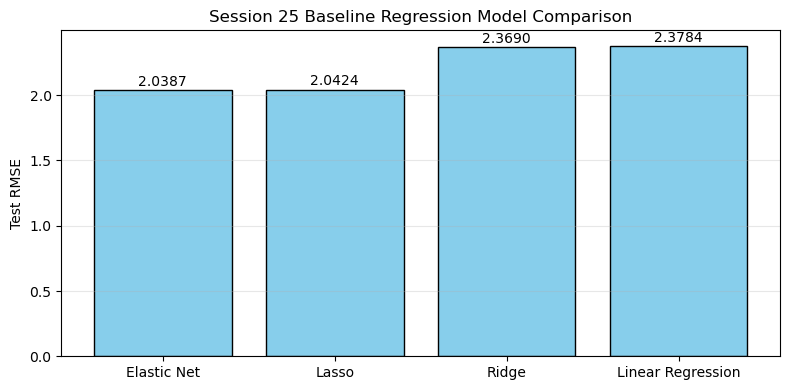

Notebook verification validation PASSED!


In [9]:
# Plot RMSE Comparison
plt.figure(figsize=(8, 4))
bars = plt.bar(baseline_rows["Model"], baseline_rows["RMSE"], color="skyblue", edgecolor="black")
plt.title("Session 25 Baseline Regression Model Comparison")
plt.ylabel("Test RMSE")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

# Programmatic Completion validation
assert len(baseline_rows) == 4
assert set(baseline_rows["Model"]) == {"Linear Regression", "Ridge", "Lasso", "Elastic Net"}
print("Notebook verification validation PASSED!")